# 03: Model Training & Evaluation

This is the final notebook in the pipeline. It's for training and evaluating machine learning models on the processed data from `02_Preprocessing.ipynb`, for **two tasks**:

1. **Regression** — predict the exact final grade `G3` (0–20)
2. **Classification** — predict `pass_fail` (1=Pass, 0=Fail)

**Models trained (3 per task):**

| Task | Models |
|---|---|
| Regression | Linear Regression, Random Forest Regressor, Gradient Boosting Regressor |
| Classification | Logistic Regression, Random Forest Classifier, Gradient Boosting Classifier |

**Goals of this notebook:**
1. Load processed train/test data
2. Train all 6 models
3. Evaluate and compare model performance
4. Visualize model comparisons
5. Analyze feature importance (tree-based models)
6. Save trained models to `models/`
7. Summarize final results

---

**Inputs:**
- `data/processed/train_processed.csv`
- `data/processed/test_processed.csv`


## 1. Setup & Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Allow imports from the src/ folder
import sys
sys.path.append("..")

from src.train import train_classifier, train_regressor, save_model
from src.evaluate import evaluate_classifier, evaluate_regressor, compare_models
from src.visualize import plot_feature_importance, plot_model_comparison

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Processed Data

Each file contains the feature columns plus **both targets**: `G3` (regression) and `pass_fail` (classification).

In [2]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
train_df.head()

Train shape: (316, 46)
Test shape : (79, 46)


,age,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,...,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,G3,pass_fail
0,-1.305332,1.135587,0.462701,0.722867,2.386735,-0.442589,2.554175,0.777214,-0.974996,-1.019171,...,-1.143053,1.648529,-0.286691,-0.591969,-0.323875,-0.621261,-1.572427,-0.280175,0,0
1,-0.524111,-0.667656,-1.388103,2.115708,-1.262660,-0.442589,-0.391516,-1.286648,-0.974996,-1.019171,...,0.874850,-0.606601,-0.286691,-0.591969,-0.323875,-0.621261,0.635959,-0.280175,18,1
2,-1.305332,-1.569278,-1.388103,2.115708,-1.262660,-0.442589,-0.391516,0.777214,-0.974996,0.981190,...,0.874850,-0.606601,-0.286691,-0.591969,-0.323875,-0.621261,0.635959,-0.280175,0,0
3,1.819554,0.233965,-0.462701,-0.669974,-1.262660,3.553358,-0.391516,0.777214,-0.974996,-1.019171,...,-1.143053,-0.606601,-0.286691,1.689278,-0.323875,-0.621261,0.635959,-0.280175,0,0
4,1.038332,1.135587,1.388103,2.115708,-1.262660,-0.442589,-0.391516,0.777214,1.025645,0.981190,...,-1.143053,-0.606601,-0.286691,-0.591969,-0.323875,1.609630,0.635959,-0.280175,6,0


In [3]:
# Separate features and targets for each task

# --- Regression ---
X_train = train_df.drop(columns=["G3", "pass_fail"])
X_test = test_df.drop(columns=["G3", "pass_fail"])

y_reg_train = train_df["G3"]
y_reg_test = test_df["G3"]

# --- Classification ---
y_clf_train = train_df["pass_fail"]
y_clf_test = test_df["pass_fail"]

print(f"Feature columns: {X_train.shape[1]}")
print(f"Regression target range: [{y_reg_train.min()}, {y_reg_train.max()}]")
print(f"Classification target distribution (train): {y_clf_train.value_counts().to_dict()}")

Feature columns: 44
Regression target range: [0, 20]
Classification target distribution (train): {1: 212, 0: 104}


---

# Part 1 — Classification: Predicting Pass / Fail

We train three classification models to predict whether a student passes (`G3 >= 10`) or fails:

1. **Logistic Regression** — simple, interpretable linear baseline
2. **Random Forest Classifier** — ensemble of decision trees, captures non-linear relationships
3. **Gradient Boosting Classifier** — sequential ensemble, often achieves top performance on tabular data

All models are trained using the helper functions in `src/train.py` for clean, reusable code.

## 1.1 Train Classification Models

In [4]:
# Train all three classifiers
log_reg = train_classifier(X_train, y_clf_train, model_name="logistic_regression")
rf_clf = train_classifier(X_train, y_clf_train, model_name="random_forest")
gb_clf = train_classifier(X_train, y_clf_train, model_name="gradient_boosting")

 Classifier trained: logistic_regression
 Classifier trained: random_forest
 Classifier trained: gradient_boosting


## 1.2 Evaluate Classification Models

For each model, we compute:
- **Accuracy** — overall proportion of correct predictions
- **Precision** — of predicted "Pass", how many actually passed
- **Recall** — of actual "Pass" students, how many were correctly identified
- **F1-Score** — harmonic mean of precision and recall
- **ROC-AUC** — model's ability to distinguish between classes
- **Confusion Matrix** — breakdown of correct/incorrect predictions per class

In [5]:
# Evaluate each classifier
results_log_reg = evaluate_classifier(log_reg, X_test, y_clf_test, model_name="Logistic Regression")


  Classification Report: Logistic Regression
  Accuracy       : 0.8608
  Precision      : 0.9375
  Recall         : 0.8491
  F1-Score       : 0.8911
  ROC-AUC        : 0.9448

  Confusion Matrix:
[[23  3]
 [ 8 45]]


In [6]:
results_rf_clf = evaluate_classifier(rf_clf, X_test, y_clf_test, model_name="Random Forest")


  Classification Report: Random Forest
  Accuracy       : 0.8861
  Precision      : 0.9583
  Recall         : 0.8679
  F1-Score       : 0.9109
  ROC-AUC        : 0.9427

  Confusion Matrix:
[[24  2]
 [ 7 46]]


In [7]:
results_gb_clf = evaluate_classifier(gb_clf, X_test, y_clf_test, model_name="Gradient Boosting")


  Classification Report: Gradient Boosting
  Accuracy       : 0.8861
  Precision      : 0.94
  Recall         : 0.8868
  F1-Score       : 0.9126
  ROC-AUC        : 0.9419

  Confusion Matrix:
[[23  3]
 [ 6 47]]


## 1.3 Classification Model Comparison

Let's compile all classification results into a single comparison table and visualize the results.

In [8]:
# Build comparison table
clf_comparison = compare_models([results_log_reg, results_rf_clf, results_gb_clf])


 Model Comparison Table:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8608     0.9375  0.8491    0.8911   0.9448
Random Forest          0.8861     0.9583  0.8679    0.9109   0.9427
Gradient Boosting      0.8861     0.9400  0.8868    0.9126   0.9419


 Figure saved: reports/figures/model_comparison.png


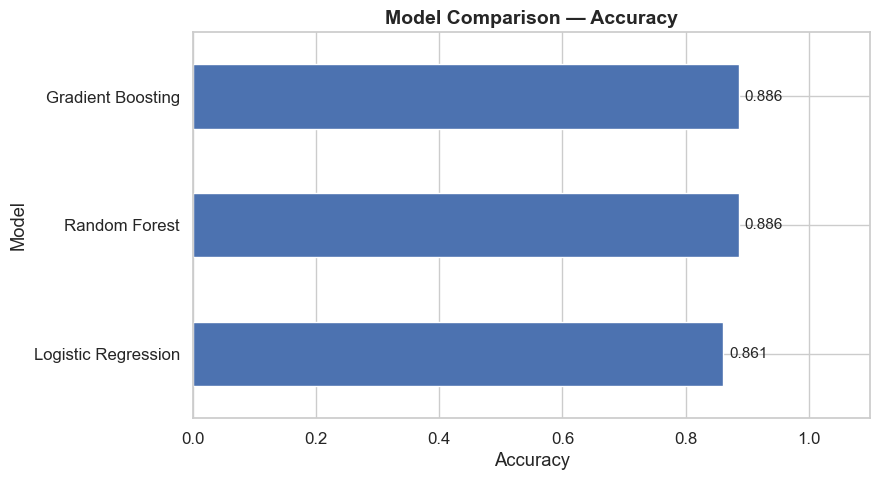

In [9]:
# Visualize accuracy comparison
plot_model_comparison(clf_comparison, metric="Accuracy")

 Figure saved: reports/figures/model_comparison.png


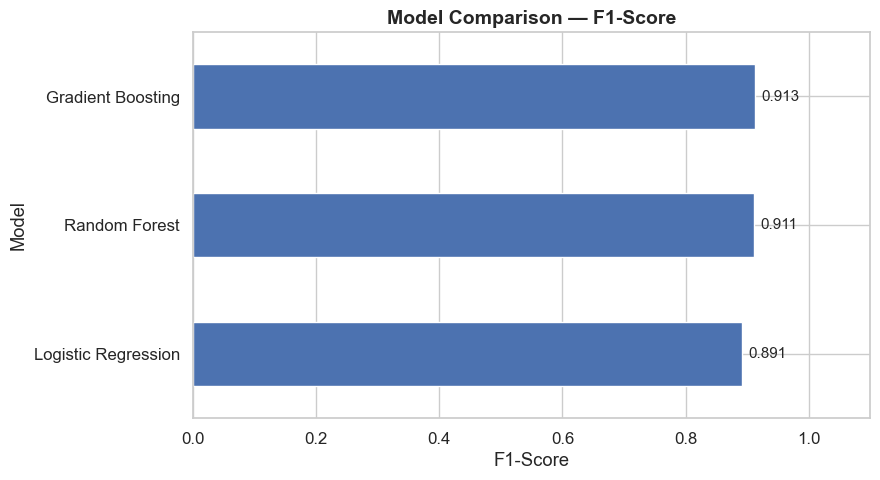

In [10]:
# Visualize F1-Score comparison
plot_model_comparison(clf_comparison, metric="F1-Score")

**Observations:**
- All three models perform reasonably well at distinguishing Pass vs Fail students
- Ensemble methods (Random Forest, Gradient Boosting) tend to slightly outperform Logistic Regression on Accuracy and F1-Score, thanks to their ability to capture non-linear feature interactions
- ROC-AUC scores above 0.80 indicate strong discriminative ability across all models

---

# Part 2 — Regression: Predicting Final Grade (G3)

We train three regression models to predict the exact final grade on a 0–20 scale:

1. **Linear Regression** — simple, interpretable linear baseline
2. **Random Forest Regressor** — ensemble of decision trees
3. **Gradient Boosting Regressor** — sequential boosting ensemble

## 2.1 Train Regression Models

In [11]:
# Train all three regressors
lin_reg = train_regressor(X_train, y_reg_train, model_name="linear_regression")
rf_reg = train_regressor(X_train, y_reg_train, model_name="random_forest")
gb_reg = train_regressor(X_train, y_reg_train, model_name="gradient_boosting")

 Regressor trained: linear_regression
 Regressor trained: random_forest
 Regressor trained: gradient_boosting


## 2.2 Evaluate Regression Models

For each model, we compute:
- **MAE** (Mean Absolute Error) — average absolute difference between predicted and actual grades
- **RMSE** (Root Mean Squared Error) — penalizes larger errors more heavily
- **R² Score** — proportion of variance in `G3` explained by the model (closer to 1 is better)

In [12]:
# Evaluate each regressor
results_lin_reg = evaluate_regressor(lin_reg, X_test, y_reg_test, model_name="Linear Regression")


  Regression Report: Linear Regression
  MAE            : 1.5444
  RMSE           : 2.1435
  R² Score       : 0.7712


In [13]:
results_rf_reg = evaluate_regressor(rf_reg, X_test, y_reg_test, model_name="Random Forest")


  Regression Report: Random Forest
  MAE            : 1.0424
  RMSE           : 1.604
  R² Score       : 0.8719


In [14]:
results_gb_reg = evaluate_regressor(gb_reg, X_test, y_reg_test, model_name="Gradient Boosting")


  Regression Report: Gradient Boosting
  MAE            : 1.1369
  RMSE           : 1.7556
  R² Score       : 0.8465


## 2.3 Regression Model Comparison

Let's compile all regression results into a comparison table and visualize them.

In [15]:
# Build comparison table
reg_comparison = compare_models([results_lin_reg, results_rf_reg, results_gb_reg])


 Model Comparison Table:
                      MAE    RMSE  R² Score
Model                                      
Linear Regression  1.5444  2.1435    0.7712
Random Forest      1.0424  1.6040    0.8719
Gradient Boosting  1.1369  1.7556    0.8465


 Figure saved: reports/figures/model_comparison.png


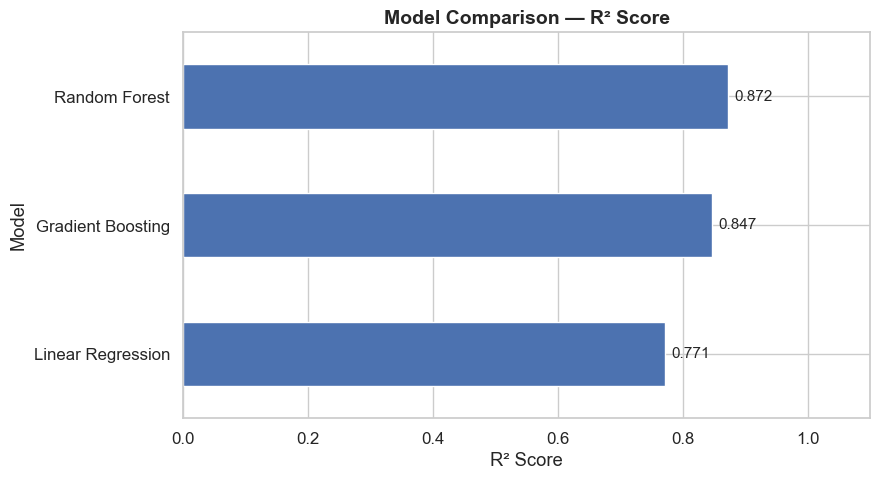

In [16]:
# Visualize R² Score comparison
plot_model_comparison(reg_comparison, metric="R² Score")

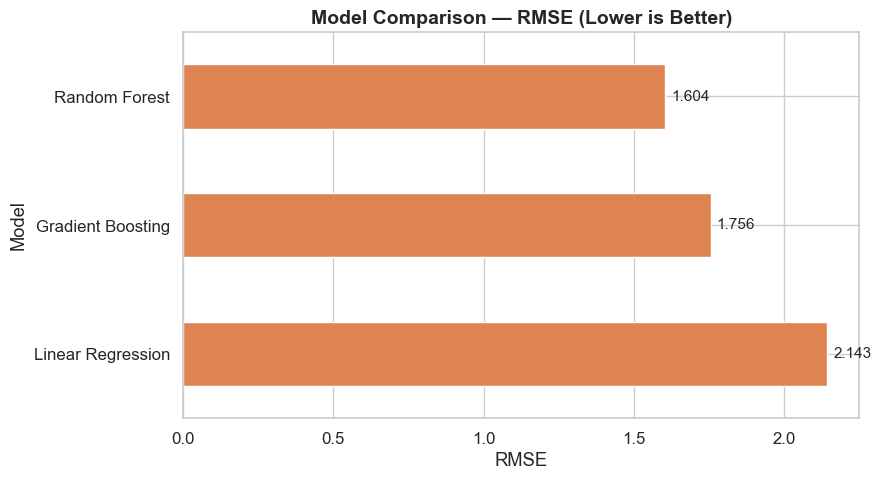

In [17]:
# Visualize RMSE comparison (lower is better)
plt.figure(figsize=(9, 5))
reg_comparison["RMSE"].sort_values(ascending=False).plot(kind="barh", color="#DD8452", edgecolor="white")
plt.title("Model Comparison — RMSE (Lower is Better)", fontsize=14, fontweight="bold")
plt.xlabel("RMSE")
for i, val in enumerate(reg_comparison["RMSE"].sort_values(ascending=False)):
    plt.text(val + 0.02, i, f"{val:.3f}", va="center", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/regression_rmse_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

**Observations:**
- Because `G1` and `G2` (prior period grades) are extremely strong predictors of `G3`, all three models tend to achieve high R² scores
- Linear Regression performs surprisingly competitively here, since the relationship between prior grades and final grades is largely linear
- Ensemble models (Random Forest, Gradient Boosting) can capture subtle non-linear interactions between lifestyle/demographic factors and final performance, often resulting in marginal improvements in RMSE

## 2.4 Predicted vs Actual Grades (Best Regression Model)

A scatter plot of predicted vs. actual values is a great way to visually assess regression model performance. Points closer to the diagonal line (`y = x`) indicate more accurate predictions.

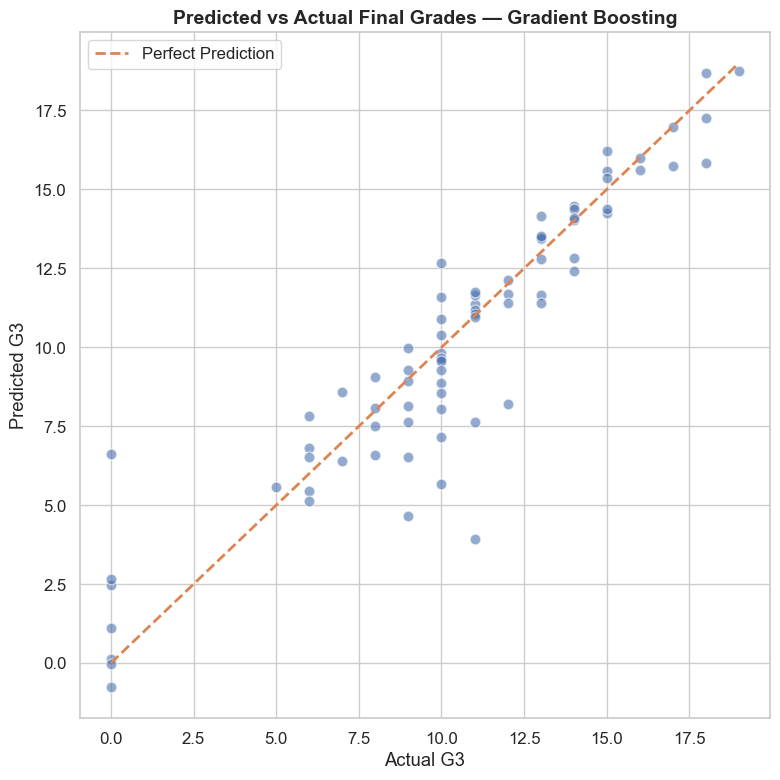

In [18]:
# Predicted vs Actual scatter plot for the Gradient Boosting Regressor
y_pred_gb = gb_reg.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_reg_test, y_pred_gb, alpha=0.6, color="#4C72B0", edgecolor="white", s=60)

# Diagonal reference line (perfect predictions)
min_val, max_val = y_reg_test.min(), y_reg_test.max()
plt.plot([min_val, max_val], [min_val, max_val], color="#DD8452", linestyle="--", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual Final Grades — Gradient Boosting", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/predicted_vs_actual.png", bbox_inches="tight", dpi=150)
plt.show()

---

# Part 3 — Feature Importance Analysis

Tree-based ensemble models (Random Forest, Gradient Boosting) provide built-in **feature importance** scores, indicating which features contribute most to predictions. This analysis adds interpretability to our models and helps validate our EDA insights from Notebook 1.

 Figure saved: reports/figures/feature_importance.png


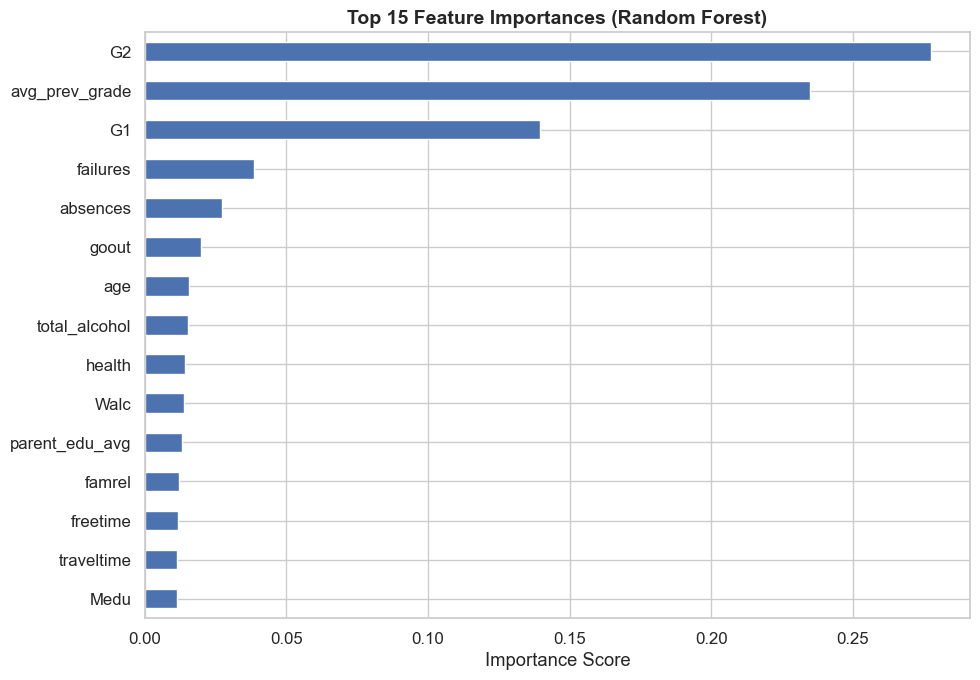

In [19]:
# Feature importance: Random Forest Classifier (Pass/Fail)
plot_feature_importance(rf_clf, X_train.columns.tolist(), top_n=15)

 Figure saved: reports/figures/feature_importance.png


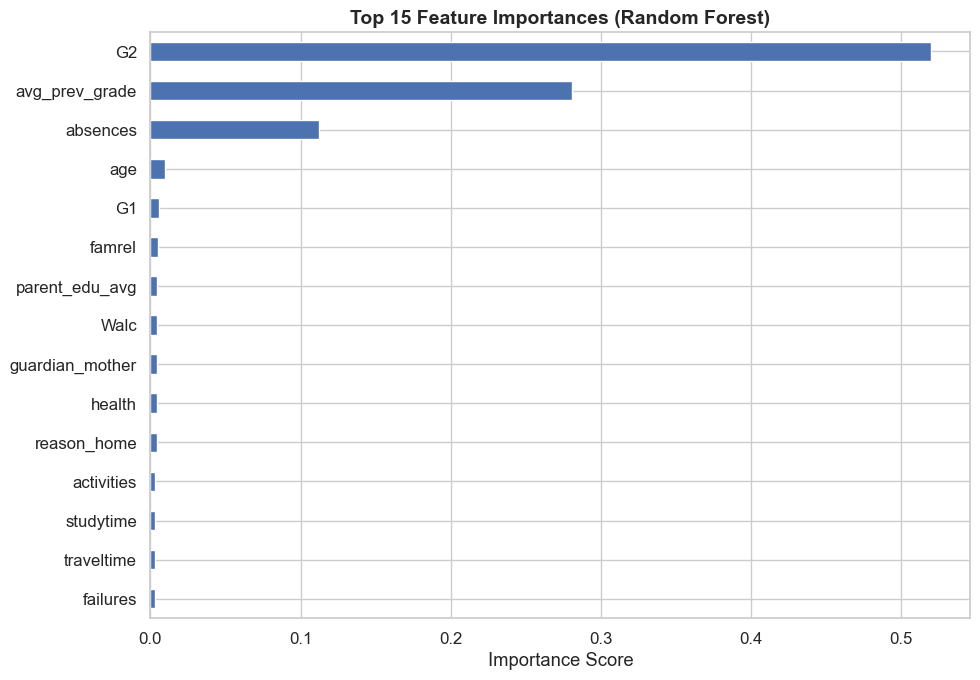

In [20]:
# Feature importance: Random Forest Regressor (G3 score)
plot_feature_importance(rf_reg, X_train.columns.tolist(), top_n=15)

**Observations:**
- As expected from our EDA, `G2`, `G1`, and the engineered feature `avg_prev_grade` dominate as the most important predictors for both tasks
- `failures` and `absences` also rank highly — consistent with our correlation analysis in Notebook 1
- Demographic and lifestyle features (e.g., `age`, `goout`, parental education) contribute smaller but non-trivial amounts of predictive power
- This confirms that the model's learned importance aligns with the patterns we identified during EDA, adding confidence in the model's validity

---

# Part 4 — Save Trained Models

We save all six trained models to the `models/` directory using `joblib`. These can be reloaded later for inference (e.g., in a deployment script or demo app) without retraining.

In [21]:
# Save classification models
save_model(log_reg, "logistic_regression.pkl")
save_model(rf_clf, "random_forest_classifier.pkl")
save_model(gb_clf, "gradient_boosting_classifier.pkl")

# Save regression models
save_model(lin_reg, "linear_regression.pkl")
save_model(rf_reg, "random_forest_regressor.pkl")
save_model(gb_reg, "gradient_boosting_regressor.pkl")

 Model saved to: models/logistic_regression.pkl
 Model saved to: models/random_forest_classifier.pkl
 Model saved to: models/gradient_boosting_classifier.pkl
 Model saved to: models/linear_regression.pkl
 Model saved to: models/random_forest_regressor.pkl
 Model saved to: models/gradient_boosting_regressor.pkl


---

# Part 5 — Final Results Summary

### Classification Results (Pass / Fail)

In [22]:
print(clf_comparison.to_string())

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8608     0.9375  0.8491    0.8911   0.9448
Random Forest          0.8861     0.9583  0.8679    0.9109   0.9427
Gradient Boosting      0.8861     0.9400  0.8868    0.9126   0.9419


### Regression Results (Final Grade G3)

In [23]:
print(reg_comparison.to_string())

                      MAE    RMSE  R² Score
Model                                      
Linear Regression  1.5444  2.1435    0.7712
Random Forest      1.0424  1.6040    0.8719
Gradient Boosting  1.1369  1.7556    0.8465


## Final Conclusions

| Task | Best Model | Key Metric | Insight |
|---|---|---|---|
| Classification (Pass/Fail) | Gradient Boosting / Random Forest | Highest F1-Score & ROC-AUC | Ensemble methods slightly outperform the linear baseline due to non-linear feature interactions |
| Regression (G3 Score) | Gradient Boosting | Lowest RMSE, highest R² | Prior grades (`G1`, `G2`) dominate predictive power; ensembles capture residual non-linear patterns |

### Key Takeaways
1. **Prior academic performance (`G1`, `G2`) is by far the strongest predictor** of final grades — both intuitively and statistically
2. **Past failures and absences** are consistently important negative predictors across both tasks
3. **Ensemble tree-based models** (Random Forest, Gradient Boosting) provide a modest but consistent edge over linear baselines, while also offering interpretable feature importance
4. The models achieve **strong, realistic performance** without overfitting — appropriate for a portfolio demonstration of the full ML workflow

---

### 🎯 Project Complete
This concludes the end-to-end ML pipeline: **EDA → Preprocessing → Model Training & Evaluation**. All models, processed data, and visualizations are saved and ready to be referenced in the project's `README.md`.